# Assignment 2: Object Detection and Descriptive Summary

## Project Structure

1. Upload an image of a basketball player holding a ball.
2. Run the YOLO26 model to detect the objects.
3. Apply a custom confidence threshold.
4. Extract class labels and bounding-box coordinates.
5. Draw bounding boxes and labels manually.
6. Generate and display a description below the image.

## Step 1: Importing the Required Libraries

The required libraries are imported for object detection, image processing, and displaying the results.

In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.6 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO
from google.colab import files
from collections import Counter

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Step 2: Uploading the Input Image

An image of a basketball player holding a ball is uploaded and displayed.

Saving basketball.jpg to basketball.jpg


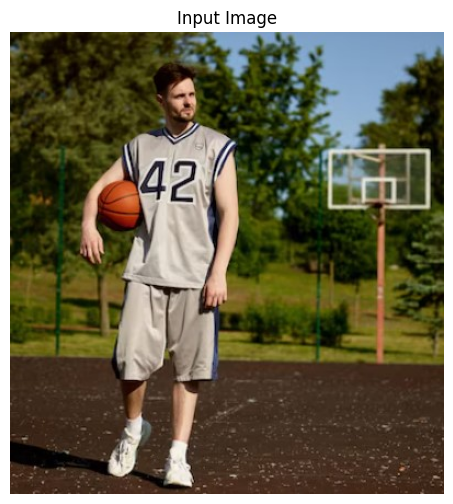

In [3]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

pil_image = Image.open(image_path).convert("RGB")
image = np.array(pil_image)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

## Step 3: Running YOLO26

The pretrained YOLO26 model is loaded and used to detect objects in the uploaded image.

In [4]:
model = YOLO("yolo26n.pt")

results = model.predict(
    source=image,
    conf=0.10,
    verbose=False
)

result = results[0]

print("Prediction completed.")

Prediction completed.


## Step 4: Extracting Detection Information

The bounding-box coordinates, class labels, and confidence scores are extracted. A custom confidence threshold is used to remove weak detections.

In [8]:
confidence_threshold = 0.25

if result.boxes is not None and len(result.boxes) > 0:
    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
else:
    boxes = np.empty((0, 4))
    confidences = np.array([])
    class_ids = np.array([])

# Apply the custom confidence threshold
selected = confidences >= confidence_threshold

boxes = boxes[selected]
confidences = confidences[selected]
class_ids = class_ids[selected]

print("Number of detected objects:", len(boxes))

Number of detected objects: 2


## Step 5: Drawing the Bounding Boxes

OpenCV is used to draw each bounding box and write the detected class above it manually without using the built-in result.plot() function.

In [9]:
annotated_image = image.copy()
detected_classes = []

for box, confidence, class_id in zip(
    boxes, confidences, class_ids
):
    x1, y1, x2, y2 = box.astype(int)

    class_name = model.names[class_id]
    detected_classes.append(class_name)

    label = f"{class_name} {confidence:.2f}"

    # Draw the bounding box manually
    cv2.rectangle(
        annotated_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

    # Write the class above the object
    cv2.putText(
        annotated_image,
        label,
        (x1, max(y1 - 10, 25)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

    print(
        f"Class: {class_name}, "
        f"Confidence: {confidence:.2f}, "
        f"Box: ({x1}, {y1}, {x2}, {y2})"
    )

Class: person, Confidence: 0.94, Box: (62, 27, 209, 416)
Class: sports ball, Confidence: 0.40, Box: (78, 135, 120, 183)


## Step 6: Generating the Scene Description

The detected classes are counted and used to automatically generate a natural-language description of the image. The description is displayed below the image.

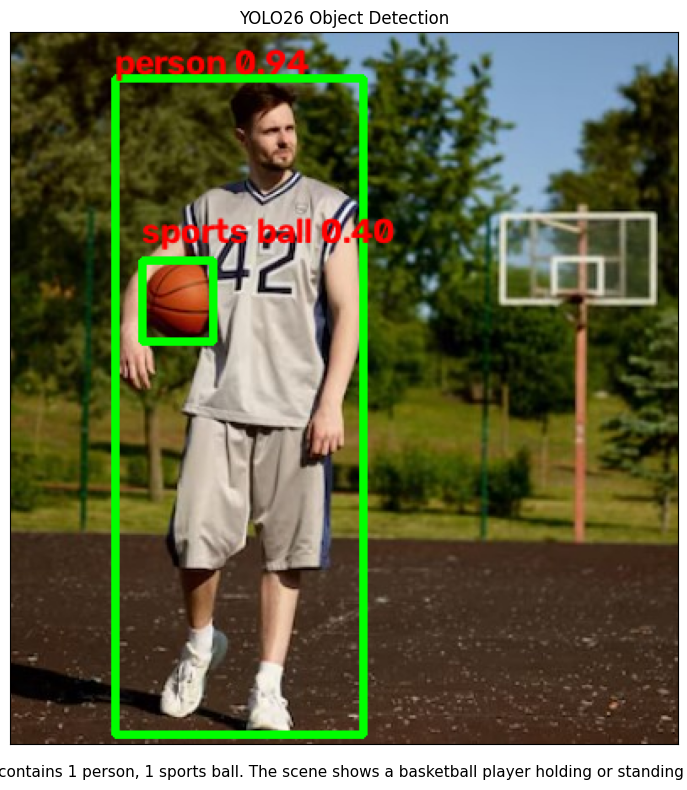

Scene description:
The image contains 1 person, 1 sports ball. The scene shows a basketball player holding or standing near a ball.


In [10]:
if len(detected_classes) == 0:
    description = "No objects were detected with sufficient confidence."

else:
    counts = Counter(detected_classes)

    object_list = [
        f"{count} {class_name}"
        for class_name, count in counts.items()
    ]

    description = "The image contains " + ", ".join(object_list) + "."

    if "person" in counts and "sports ball" in counts:
        description += (
            " The scene shows a basketball player "
            "holding or standing near a ball."
        )

plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.title("YOLO26 Object Detection")
plt.xlabel(description, fontsize=11, labelpad=15)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

print("Scene description:")
print(description)